# A Simplified Strategy for Handling Incidental Clustering

### Paul N Zivich, Jessie K Edwards, Bonnie E Shook-Sa, Stephen R Cole

The following notebook recreates the application results presented in the manuscript.
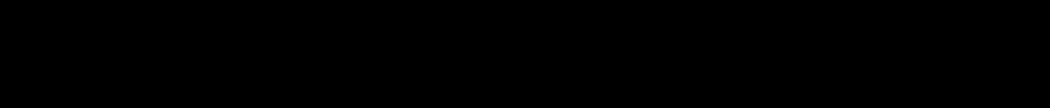

In [1]:
import numpy as np
import scipy as sp
import pandas as pd
import delicatessen as deli
from delicatessen import MEstimator
from delicatessen.estimating_equations import ee_regression
from delicatessen.utilities import inverse_logit, aggregate_efuncs
from formulaic import model_matrix

print("Versions")
print("NumPy:       ", np.__version__)
print("SciPy:       ", sp.__version__)
print("Pandas:      ", pd.__version__)
print("Delicatessen:", deli.__version__)

Versions
NumPy:        2.3.5
SciPy:        1.16.3
Pandas:       2.3.3
Delicatessen: 4.3


In [2]:
# Setting up the data
d = pd.read_csv("data/cbihs.csv")
d['no_test'] = np.where(d['hiv_test'].isna(), 1, 0)
d['ever_test'] = np.where(d['ever_test'] == 1, 1, 0)

In [3]:
# Setup variable types for delicatessen
y_no_nan = np.asarray(d['hiv_test'].fillna(-999))
r = np.where(d['hiv_test'].isna(), 0, 1)
y = np.asarray(d['hiv_test'])
W = model_matrix("female + C(educ) + age + sexual_debut + ever_test + C(country)", d)
g = np.asarray(d['venue_id'])

### Complete-Case Analysis

In [4]:
def psi_completecase(theta):
    return d['hiv_test'].dropna() - theta


def psi_completecase_cluster(theta):
    return aggregate_efuncs(psi_completecase(theta), group=np.asarray(d.dropna(subset=['hiv_test'])['venue_id']))

In [5]:
init_vals = [0.05]
estr = MEstimator(psi_completecase, init=init_vals)
estr.estimate()
estr.print_results(decimals=3)

              Estimation Method: M-estimator
--------------------------------------------------------------
No. Observations:       10507 | No. Parameters:              1
Solving algorithm:         lm | Max Iterations:           5000
Solving tolerance:      1e-09 | Allow P-Inverse:             1
Derivative Method:     approx | Deriv Approx:            1e-09
Small N Correction:      None | Distribution:           Z-stat
   Theta   StdErr  Z-score      LCL      UCL  P-value  S-value 
--------------------------------------------------------------
   0.045    0.002   22.231    0.041    0.049    0.000  361.294 


In [6]:
estr = MEstimator(psi_completecase_cluster, init=init_vals)
estr.estimate()
estr.print_results(decimals=3)

              Estimation Method: M-estimator
--------------------------------------------------------------
No. Observations:         452 | No. Parameters:              1
Solving algorithm:         lm | Max Iterations:           5000
Solving tolerance:      1e-09 | Allow P-Inverse:             1
Derivative Method:     approx | Deriv Approx:            1e-09
Small N Correction:      None | Distribution:           Z-stat
   Theta   StdErr  Z-score      LCL      UCL  P-value  S-value 
--------------------------------------------------------------
   0.045    0.003   17.457    0.040    0.050    0.000  224.283 


### Missingness Bounds

In [7]:
def psi_bounds(theta):
    mu_lower, mu_upper = theta

    # Lower bound estimate
    ee_lower = np.asarray(d['hiv_test'].fillna(0)) - mu_lower

    # Upper bound estimate
    ee_upper = np.asarray(d['hiv_test'].fillna(1)) - mu_upper

    # Stacking estimating functions
    return np.vstack([ee_lower, ee_upper])


def psi_bounds_cluster(theta):
    return aggregate_efuncs(psi_bounds(theta), group=g)

In [8]:
init_vals = [0.05, 0.05]
estr = MEstimator(psi_bounds, init=init_vals)
estr.estimate()
estr.print_results(decimals=3)

              Estimation Method: M-estimator
--------------------------------------------------------------
No. Observations:       11378 | No. Parameters:              2
Solving algorithm:         lm | Max Iterations:           5000
Solving tolerance:      1e-09 | Allow P-Inverse:             1
Derivative Method:     approx | Deriv Approx:            1e-09
Small N Correction:      None | Distribution:           Z-stat
   Theta   StdErr  Z-score      LCL      UCL  P-value  S-value 
--------------------------------------------------------------
   0.041    0.002   22.191    0.038    0.045    0.000  360.012 
   0.118    0.003   39.022    0.112    0.124    0.000      inf 


In [9]:
estr = MEstimator(psi_bounds_cluster, init=init_vals)
estr.estimate()
estr.print_results(decimals=3)

              Estimation Method: M-estimator
--------------------------------------------------------------
No. Observations:         452 | No. Parameters:              2
Solving algorithm:         lm | Max Iterations:           5000
Solving tolerance:      1e-09 | Allow P-Inverse:             1
Derivative Method:     approx | Deriv Approx:            1e-09
Small N Correction:      None | Distribution:           Z-stat
   Theta   StdErr  Z-score      LCL      UCL  P-value  S-value 
--------------------------------------------------------------
   0.041    0.002   17.348    0.037    0.046    0.000  221.547 
   0.118    0.007   17.790    0.105    0.131    0.000  232.790 


### Augmented Inverse Probability Weighting for Missing

In [10]:
def psi_aipw(theta):
    mu = theta[0]
    alpha = theta[1: 1+W.shape[1]]
    beta = theta[1+W.shape[1]:]

    # Missingness score model
    ee_psm = ee_regression(theta=alpha, y=r, X=W, model='logistic')
    pi = inverse_logit(np.dot(W, alpha))
    ipmw = r / pi

    # Outcome nuisance model
    ee_out = ee_regression(theta=beta, y=y_no_nan, X=W, model='logistic', weights=ipmw) * r
    yhat = inverse_logit(np.dot(W, beta))

    # Estimator
    ee_mu = yhat - mu
    return np.vstack([ee_mu, ee_psm, ee_out])


def psi_aipw_cluster(theta):
    psi_i = psi_aipw(theta=theta)
    return aggregate_efuncs(psi_i, group=g)

In [11]:
init_vals = [0.2, ] + [0., ]*W.shape[1]*2
estr = MEstimator(psi_aipw, init=init_vals)
estr.estimate()
estr.print_results(subset=[0, ], decimals=3)

              Estimation Method: M-estimator
--------------------------------------------------------------
No. Observations:       11378 | No. Parameters:             27
Solving algorithm:         lm | Max Iterations:           5000
Solving tolerance:      1e-09 | Allow P-Inverse:             1
Derivative Method:     approx | Deriv Approx:            1e-09
Small N Correction:      None | Distribution:           Z-stat
   Theta   StdErr  Z-score      LCL      UCL  P-value  S-value 
--------------------------------------------------------------
   0.044    0.002   22.197    0.041    0.048    0.000  360.211 


In [12]:
estr = MEstimator(psi_aipw_cluster, init=init_vals)
estr.estimate()
estr.print_results(subset=[0, ], decimals=3)

              Estimation Method: M-estimator
--------------------------------------------------------------
No. Observations:         452 | No. Parameters:             27
Solving algorithm:         lm | Max Iterations:           5000
Solving tolerance:      1e-09 | Allow P-Inverse:             1
Derivative Method:     approx | Deriv Approx:            1e-09
Small N Correction:      None | Distribution:           Z-stat
   Theta   StdErr  Z-score      LCL      UCL  P-value  S-value 
--------------------------------------------------------------
   0.044    0.003   17.367    0.039    0.050    0.000  222.013 


END